# Ajuste BEG con BASELINE en picos dQdV

In [1]:
from pathlib import Path
import numpy as np
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.signal import savgol_filter
import func_deriv as func_deriv
import func_plots as func_plots
from scipy.optimize import curve_fit
from scipy.signal import find_peaks


In [2]:
# %% ------- Cargar ciclos ------------------------------------------------------------
input_folder = Path('/home/mariajose/proc-icdv/tmp')
nombre_archivo = "NMC-20"
output_folder = Path('/home/mariajose/proc-icdv/output')
output_folder.mkdir(parents=True, exist_ok=True)  # Create output directory if it doesn't exist

with open(input_folder / f'{nombre_archivo}.json') as f_json:
    raw_dict = json.load(f_json)

dict_ciclos_sep = {
    int(ciclo): {
        etapa: pd.DataFrame(data) for etapa, data in etapas.items()
    }
    for ciclo, etapas in raw_dict.items()
}

indices_ciclos = list(dict_ciclos_sep.keys())

In [3]:
# %% ------- Elegir ciclos ------------------------------------------------------------

# Elijo en todo el rango, equiespaciados
N_ciclos = 10  # Número de ciclos a tomar, si no se especifica, toma todos los del archivo
indices_ciclos_ = indices_ciclos[:-1] # Quito el último
indices_ciclos_array = np.array(indices_ciclos_)
ciclos_disponibles = sorted(dict_ciclos_sep.keys())
ciclos_seleccionados = indices_ciclos_array[np.linspace(0, len(indices_ciclos_array)-1, N_ciclos, dtype=int)]
#print("Ciclos seleccionados:", ciclos_seleccionados)
#print(f"son {len(ciclos_seleccionados)} ciclos")

# Elecciones manuales
#ciclos_reducidos = [3, 21, 78, 153, 228, 303, 378, 453, 528, 603, 678, 753, 828]
#ciclos_seleccionados = [2, 99, 192, 300, 414, 504, 600, 702, 801, 897]
ciclos_seleccionados = [2, 21, 99, 198, 297, 396, 498, 597, 696, 795, 897]
ciclos_seleccionados = [21, 99, 198, 297, 396, 498, 597, 696, 795, 897]


excluir = {30, 32, 34, 35, 38, 88, 186, 187, 188, 189, 190, 191, 192, 193, 202, 247} # ciclos feos
ciclos_seleccionados = [c for c in ciclos_disponibles if 21 <= c <= 300 and c not in excluir]

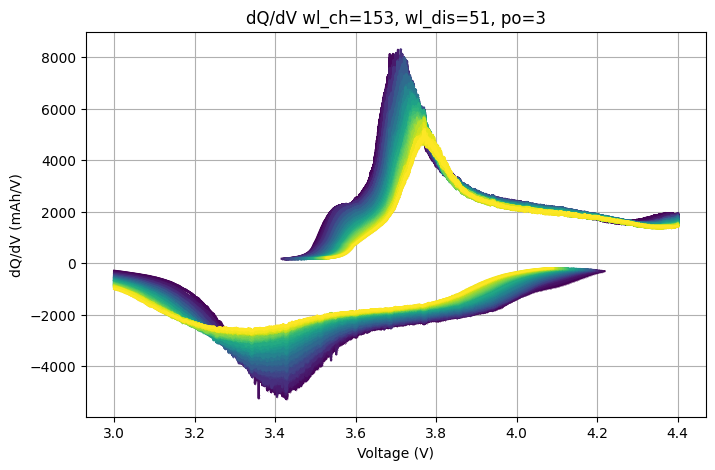

"\ndiccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},\n        99: {'Ch': df_ch_99, 'Dis': df_dis_99},\n        ...\n        }\n"

In [4]:
# %% ------- Trunco datos y calculo derivada ------------------------------------------------------------

# charge (wl = 153, truncar los n=30 puntos iniciales)
# discharge (wl = 51 = 153 / 3, truncar los n=10=30/3 puntos finales)

diccio = func_deriv.truncar_señal(ciclos_seleccionados, dict_ciclos_sep)
diccio =  func_deriv.plot_dqdv(ciclos_seleccionados, diccio)

'''
diccio = {21: {'Ch': df_ch_21, 'Dis': df_dis_21},
        99: {'Ch': df_ch_99, 'Dis': df_dis_99},
        ...
        }
'''
# Exportar a csv para trabajar en Origin
#dict[21]['Ch'].to_csv(output_folder / 'df_ch_21.csv', index=False)
#dict[21]['Dis'].to_csv(output_folder / 'df_dis_21.csv', index=False)

In [ ]:
# %% ------- Defino funciones ajuste ------------------------------------------------------------

from scipy.special import erfc
import numpy as np

def emg(x, a, mu, sigma, lambd):
    """
    Exponentially Modified Gaussian (EMG)
    
    x: array de valores
    a: amplitud
    mu: media de la gaussiana
    sigma: desviación estándar
    lambd: parámetro de decaimiento exponencial (1/tau)
    """
    return (a * (lambd/2) *
            np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
            erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))


def multi_emg(x, *params):
    """
    params: [a1, mu1, sigma1, lambda1, a2, mu2, sigma2, lambda2, ...]
    """
    y = np.zeros_like(x)
    for i in range(0, len(params), 4):
        a, mu, sigma, lambd = params[i:i+4]
        y += (a * (lambd/2) *
              np.exp((lambd/2)*(2*mu + lambd*sigma**2 - 2*x)) *
              erfc((mu + lambd*sigma**2 - x) / (np.sqrt(2)*sigma)))
    return y

In [ ]:
# parámetros iniciales para cada pico (a, mu, sigma)
p_ini = [
    900, 3.55, 0.02,   # pico 1
    5900, 3.6, 0.013,  # pico 2
    11000, 4.0, 0.02,    # pico 3
    2200, 4.39, 0.1     # pico 4
]

n_peaks = len(p_ini) // 3

# valores iniciales de lambda elegidos a mano, uno por pico
lambda_inis = [
    0.7,   # lambda inicial para pico 1
    4,  # lambda inicial para pico 2
    5,  # lambda inicial para pico 3
    100.0  # lambda inicial para pico 4
]

# construir p_ini_emg
p_ini_emg = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    p_ini_emg += [a0, mu0, sigma0, lam0]

# bounds: podés también personalizar cada lambda
lb = []
ub = []
for i in range(n_peaks):
    a0, mu0, sigma0 = p_ini[3*i:3*i+3]
    lam0 = lambda_inis[i]
    lb += [0, mu0-0.05, 1e-6, lam0*0.1]  # lambda >= 10% del inicial
    ub += [np.inf, mu0+0.05, np.inf, lam0*10]  # lambda <= 10x inicial

bounds_emg = (lb, ub)


/home/mariajose/proc-icdv/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


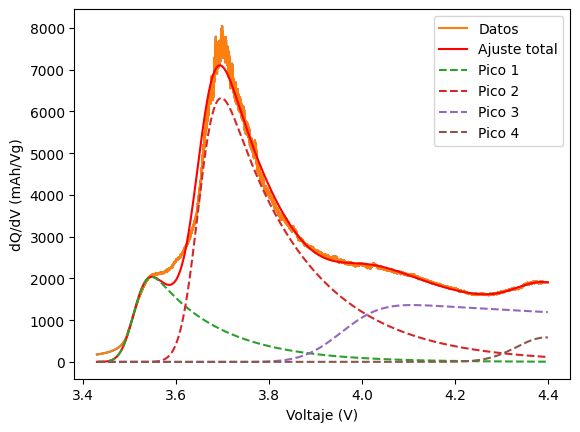

Parámetros ajustados (a, mu, sigma, lambda) por pico:
Pico 1: a=402.533244191912, mu=3.510705115876643, sigma=0.023230011344845983, lambda=6.999999999999999
Pico 2: a=1548.485911429522, mu=3.6499999999999995, sigma=0.030944899415585873, lambda=5.798316970139763
Pico 3: a=2973.5870307966998, mu=3.9572657668056452, sigma=0.06618178685907185, lambda=0.5000000000004305
Pico 4: a=94.59877084967961, mu=4.394088880188383, sigma=0.06420755983235149, lambda=379.0424807124558


In [ ]:
# %% ------- Pruebo con el primer ciclo ------------------------------------------------------------

df_ch = diccio[21]['Ch']
df_dis = diccio[21]['Dis']

dqdv_ch_calc = df_ch['dqdv_ch_calc']
V = df_ch['V_ch_savgol'] 

plt.plot(V, dqdv_ch_calc)

# Ajuste
popt, pcov = curve_fit(multi_emg, V, dqdv_ch_calc, p0=p_ini_emg, bounds=bounds_emg)

# Curva total ajustada
y_fit = multi_emg(V, *popt)
plt.plot(V, dqdv_ch_calc, label="Datos")
plt.plot(V, y_fit, 'r-', label="Ajuste total")

# Dibujar cada gaussiana individual
for i in range(0, len(popt), 4):
    a, mu, sigma, lambd = popt[i:i+4]
    plt.plot(V, emg(V, a, mu, sigma, lambd), '--', label=f"Pico {i//4 + 1}")

plt.legend()
plt.xlabel("Voltaje (V)")
plt.ylabel("dQ/dV (mAh/Vg)")
plt.savefig(f'./output/ajuste_picos.png', dpi=300)
plt.show()

print("Parámetros ajustados (a, mu, sigma, lambda) por pico:")
for i in range(n_peaks):
    a, mu, sigma, lambd = popt[i*4:i*4+4]
    print(f"Pico {i+1}: a={a}, mu={mu}, sigma={sigma}, lambda={lambd}")